## Complete Code

In [10]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime
import csv

def read(instance_file):
    name = None
    dimension = None
    coords = []
    in_coord_section = False

    with open(instance_file, 'r') as infile:
        for line in infile:
            line = line.strip()
            if not line:
                continue

            if line.startswith("NODE_COORD_SECTION"):
                in_coord_section = True
                continue

            if not in_coord_section:
                if line.startswith("NAME"):
                    name = line.split(":", 1)[1].strip()
                elif line.startswith("DIMENSION"):
                    dimension = int(line.split(":", 1)[1].strip())
                continue

            if line.startswith("EOF"):
                break

            parts = line.split()
            if len(parts) < 3:
                continue

            _, x, y = parts[:3]
            coords.append([float(x), float(y)])

    return np.array(coords)


def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        path_length += distances[path[i]][path[i + 1]]
    return path_length


def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)


def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu

    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp


def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances,
                                                  delta, beta, mu, 0) for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]


def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])


def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            delta_pheromones[path[i]][path[i + 1]] += rewards

    pheromones += -rho * pheromones + delta_pheromones


def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_length = calculate_path_length(new_path, distances)
                if new_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_length
                    improved = True
        path = best_path
    return best_path


def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants,
                num_local_search_iterations, gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate,
                w_reward, rho, delta, beta, mu):

    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))

    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)

        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))

                allowed = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]

                if hop == num_cities - 1:
                    next_city = paths[ant][0]
                else:
                    next_city = choose_next_city(current_city, allowed, q_table, pheromones,
                                                 local_epsilon, distances, delta, beta, mu)

                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]

            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)

        best = np.argmin(path_lengths)
        best_path = paths[best]
        best_len = path_lengths[best]

        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_len = calculate_path_length(new_path, distances)
            if new_len < best_len:
                best_path = new_path
                best_len = new_len

        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)

        local_alpha *= 1 / (1 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)

    return best_path


global_params = {
    "alpha": 0.4,
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,
    "epsilon": 0.4,
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,
    "w_reward": 10,
    "num_local_search_iterations": 25,
    "mu": 2,
    "delta": 2,
    "beta": 3
}


def run_trial(trial, num_cities, distances, global_params):
    start = datetime.now()

    best_path = hybrid_qaco(
        global_params["alpha"], global_params["epsilon"],
        num_cities, distances,
        global_params["num_episodes"], global_params["num_ants"],
        global_params["num_local_search_iterations"], global_params["gamma"],
        global_params["alpha_decay_rate"], global_params["epsilon_min"],
        global_params["epsilon_decay_rate"], global_params["w_reward"],
        global_params["rho"], global_params["delta"], global_params["beta"],
        global_params["mu"]
    )

    length = calculate_path_length(best_path, distances)
    end = datetime.now()
    return trial, length, (end - start).total_seconds()



# ============================
#     RUN OVER INSTANCES
# ============================

instances_dir = 'Instances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

os.makedirs("Results", exist_ok=True)

algorithm = "CompleteAlgorithm"

for instance_file in instance_files:
    instance_name = os.path.basename(instance_file).replace(".tsp", "")

    print("\n=============================================")
    print(f"Processing instance: {instance_name}")

    # CSV for this instance only
    csv_file = f"Results/{instance_name}_{algorithm}.csv"

    with open(csv_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Instance", "Algorithm", "Trial", "PathLength", "TimeSeconds"])

        cities = read(instance_file)
        num_cities = len(cities)

        distances = np.sqrt(
            (cities[:, None, 0] - cities[None, :, 0]) ** 2 +
            (cities[:, None, 1] - cities[None, :, 1]) ** 2
        )

        num_trials = 20
        results = []

        with ProcessPoolExecutor(max_workers=num_trials) as executor:
            futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                       for trial in range(1, num_trials + 1)]

            for future in as_completed(futures):
                trial, length, tsec = future.result()
                results.append((trial, length, tsec))

        results.sort(key=lambda x: x[0])

        for trial, length, tsec in results:
            writer.writerow([instance_name, algorithm, trial, length, tsec])

    print(f"Saved CSV: {csv_file}")



Processing instance: pr226
Saved CSV: Results/pr226_CompleteAlgorithm.csv

Processing instance: pr152
Saved CSV: Results/pr152_CompleteAlgorithm.csv

Processing instance: bier127
Saved CSV: Results/bier127_CompleteAlgorithm.csv

Processing instance: ch150
Saved CSV: Results/ch150_CompleteAlgorithm.csv

Processing instance: u159
Saved CSV: Results/u159_CompleteAlgorithm.csv


## Q-learning + 2Opt (ACO Removed)

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime
import csv

def read(instance_file):
    name = None
    dimension = None
    coords = []
    in_coord_section = False

    with open(instance_file, 'r') as infile:
        for line in infile:
            line = line.strip()
            if not line:
                continue

            if line.startswith("NODE_COORD_SECTION"):
                in_coord_section = True
                continue

            if not in_coord_section:
                if line.startswith("NAME"):
                    name = line.split(":", 1)[1].strip()
                elif line.startswith("DIMENSION"):
                    dimension = int(line.split(":", 1)[1].strip())
                continue

            if line.startswith("EOF"):
                break

            parts = line.split()
            if len(parts) < 3:
                continue

            _, x, y = parts[:3]
            coords.append([float(x), float(y)])

    return np.array(coords)


def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        path_length += distances[path[i]][path[i + 1]]
    return path_length


def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)


def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu

    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp


def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances,
                                                  delta, beta, mu, 0) for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]


def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])


def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            delta_pheromones[path[i]][path[i + 1]] += rewards

    pheromones += -rho * pheromones + delta_pheromones


def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_length = calculate_path_length(new_path, distances)
                if new_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_length
                    improved = True
        path = best_path
    return best_path


def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants,
                num_local_search_iterations, gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate,
                w_reward, rho, delta, beta, mu):

    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))

    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)

        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))

                allowed = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]

                if hop == num_cities - 1:
                    next_city = paths[ant][0]
                else:
                    next_city = choose_next_city(current_city, allowed, q_table, pheromones,
                                                 local_epsilon, distances, delta, beta, mu)

                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]

            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)

        best = np.argmin(path_lengths)
        best_path = paths[best]
        best_len = path_lengths[best]

        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_len = calculate_path_length(new_path, distances)
            if new_len < best_len:
                best_path = new_path
                best_len = new_len

        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)

        local_alpha *= 1 / (1 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)

    return best_path


global_params = {
    "alpha": 0.5,
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,
    "epsilon": 1.0,
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,
    "w_reward": 10,
    "num_local_search_iterations": 25,
    "mu": 2,
    "delta": 0,
    "beta": 3
}


def run_trial(trial, num_cities, distances, global_params):
    start = datetime.now()

    best_path = hybrid_qaco(
        global_params["alpha"], global_params["epsilon"],
        num_cities, distances,
        global_params["num_episodes"], global_params["num_ants"],
        global_params["num_local_search_iterations"], global_params["gamma"],
        global_params["alpha_decay_rate"], global_params["epsilon_min"],
        global_params["epsilon_decay_rate"], global_params["w_reward"],
        global_params["rho"], global_params["delta"], global_params["beta"],
        global_params["mu"]
    )

    length = calculate_path_length(best_path, distances)
    end = datetime.now()
    return trial, length, (end - start).total_seconds()




instances_dir = 'Instances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

os.makedirs("Results", exist_ok=True)
csv_file = "Results/Qlearning-2OptAlgorithm.csv"

with open(csv_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Instance", "Algorithm", "Trial", "PathLength", "TimeSeconds"])

    algorithm = "Qlearning-2OptAlgorithm"

    for instance_file in instance_files:
        instance_name = os.path.basename(instance_file).replace(".tsp", "")

        print("\n=============================================")
        print(f"Processing instance: {instance_name}")

        cities = read(instance_file)
        num_cities = len(cities)

        distances = np.sqrt(
            (cities[:, None, 0] - cities[None, :, 0]) ** 2 +
            (cities[:, None, 1] - cities[None, :, 1]) ** 2
        )

        num_trials = 20
        results = []

        with ProcessPoolExecutor(max_workers=num_trials) as executor:
            futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                       for trial in range(1, num_trials + 1)]

            for future in as_completed(futures):
                trial, length, tsec = future.result()
                results.append((trial, length, tsec))

        results.sort(key=lambda x: x[0])

        for trial, length, tsec in results:
            writer.writerow([instance_name, algorithm, trial, length, tsec])

print("\nSaved master CSV at:", csv_file)



Processing instance: gr137

Processing instance: st70

Processing instance: u159

Processing instance: att48

Processing instance: gr96

Processing instance: rat99

Saved master CSV at: Results/Qlearning-2OptAlgorithm.csv


## Q-learning + ACO (2-Opt Removed)

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime
import csv

def read(instance_file):
    name = None
    dimension = None
    coords = []
    in_coord_section = False

    with open(instance_file, 'r') as infile:
        for line in infile:
            line = line.strip()
            if not line:
                continue

            if line.startswith("NODE_COORD_SECTION"):
                in_coord_section = True
                continue

            if not in_coord_section:
                if line.startswith("NAME"):
                    name = line.split(":", 1)[1].strip()
                elif line.startswith("DIMENSION"):
                    dimension = int(line.split(":", 1)[1].strip())
                continue

            if line.startswith("EOF"):
                break

            parts = line.split()
            if len(parts) < 3:
                continue

            _, x, y = parts[:3]
            coords.append([float(x), float(y)])

    return np.array(coords)


def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        path_length += distances[path[i]][path[i + 1]]
    return path_length


def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)


def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu

    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp


def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances,
                                                  delta, beta, mu, 0) for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]


def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])


def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            delta_pheromones[path[i]][path[i + 1]] += rewards

    pheromones += -rho * pheromones + delta_pheromones


def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_length = calculate_path_length(new_path, distances)
                if new_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_length
                    improved = True
        path = best_path
    return best_path


def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants,
                num_local_search_iterations, gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate,
                w_reward, rho, delta, beta, mu):

    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))

    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)

        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))

                allowed = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]

                if hop == num_cities - 1:
                    next_city = paths[ant][0]
                else:
                    next_city = choose_next_city(current_city, allowed, q_table, pheromones,
                                                 local_epsilon, distances, delta, beta, mu)

                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]

            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)

        best = np.argmin(path_lengths)
        best_path = paths[best]
        best_len = path_lengths[best]

        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_len = calculate_path_length(new_path, distances)
            if new_len < best_len:
                best_path = new_path
                best_len = new_len

        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)

        local_alpha *= 1 / (1 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)

    return best_path


global_params = {
    "alpha": 0.5,
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,
    "epsilon": 1.0,
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,
    "w_reward": 10,
    "num_local_search_iterations": 0,
    "mu": 2,
    "delta": 2,
    "beta": 3
}


def run_trial(trial, num_cities, distances, global_params):
    start = datetime.now()

    best_path = hybrid_qaco(
        global_params["alpha"], global_params["epsilon"],
        num_cities, distances,
        global_params["num_episodes"], global_params["num_ants"],
        global_params["num_local_search_iterations"], global_params["gamma"],
        global_params["alpha_decay_rate"], global_params["epsilon_min"],
        global_params["epsilon_decay_rate"], global_params["w_reward"],
        global_params["rho"], global_params["delta"], global_params["beta"],
        global_params["mu"]
    )

    length = calculate_path_length(best_path, distances)
    end = datetime.now()
    return trial, length, (end - start).total_seconds()




instances_dir = 'Instances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

os.makedirs("Results", exist_ok=True)
csv_file = "Results/Qlearning-ACOAlgorithm.csv"

with open(csv_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Instance", "Algorithm", "Trial", "PathLength", "TimeSeconds"])

    algorithm = "Qlearning-ACOAlgorithm"

    for instance_file in instance_files:
        instance_name = os.path.basename(instance_file).replace(".tsp", "")

        print("\n=============================================")
        print(f"Processing instance: {instance_name}")

        cities = read(instance_file)
        num_cities = len(cities)

        distances = np.sqrt(
            (cities[:, None, 0] - cities[None, :, 0]) ** 2 +
            (cities[:, None, 1] - cities[None, :, 1]) ** 2
        )

        num_trials = 20
        results = []

        with ProcessPoolExecutor(max_workers=num_trials) as executor:
            futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                       for trial in range(1, num_trials + 1)]

            for future in as_completed(futures):
                trial, length, tsec = future.result()
                results.append((trial, length, tsec))

        results.sort(key=lambda x: x[0])

        for trial, length, tsec in results:
            writer.writerow([instance_name, algorithm, trial, length, tsec])

print("\nSaved master CSV at:", csv_file)



Processing instance: gr137

Processing instance: st70

Processing instance: u159

Processing instance: att48

Processing instance: gr96

Processing instance: rat99

Saved master CSV at: Results/Qlearning-ACOAlgorithm.csv


## ACO + 2-Opt (Q-learning Removed)

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime
import csv

def read(instance_file):
    name = None
    dimension = None
    coords = []
    in_coord_section = False

    with open(instance_file, 'r') as infile:
        for line in infile:
            line = line.strip()
            if not line:
                continue

            if line.startswith("NODE_COORD_SECTION"):
                in_coord_section = True
                continue

            if not in_coord_section:
                if line.startswith("NAME"):
                    name = line.split(":", 1)[1].strip()
                elif line.startswith("DIMENSION"):
                    dimension = int(line.split(":", 1)[1].strip())
                continue

            if line.startswith("EOF"):
                break

            parts = line.split()
            if len(parts) < 3:
                continue

            _, x, y = parts[:3]
            coords.append([float(x), float(y)])

    return np.array(coords)


def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        path_length += distances[path[i]][path[i + 1]]
    return path_length


def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)


def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu

    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp


def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances,
                                                  delta, beta, mu, 0) for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]


def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])


def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            delta_pheromones[path[i]][path[i + 1]] += rewards

    pheromones += -rho * pheromones + delta_pheromones


def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_length = calculate_path_length(new_path, distances)
                if new_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_length
                    improved = True
        path = best_path
    return best_path


def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants,
                num_local_search_iterations, gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate,
                w_reward, rho, delta, beta, mu):

    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))

    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)

        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))

                allowed = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]

                if hop == num_cities - 1:
                    next_city = paths[ant][0]
                else:
                    next_city = choose_next_city(current_city, allowed, q_table, pheromones,
                                                 local_epsilon, distances, delta, beta, mu)

                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]

            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)

        best = np.argmin(path_lengths)
        best_path = paths[best]
        best_len = path_lengths[best]

        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_len = calculate_path_length(new_path, distances)
            if new_len < best_len:
                best_path = new_path
                best_len = new_len

        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)

        local_alpha *= 1 / (1 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)

    return best_path


global_params = {
    "alpha": 0.5,
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,
    "epsilon": 1.0,
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,
    "w_reward": 10,
    "num_local_search_iterations": 25,
    "mu": 0,
    "delta": 2,
    "beta": 3
}


def run_trial(trial, num_cities, distances, global_params):
    start = datetime.now()

    best_path = hybrid_qaco(
        global_params["alpha"], global_params["epsilon"],
        num_cities, distances,
        global_params["num_episodes"], global_params["num_ants"],
        global_params["num_local_search_iterations"], global_params["gamma"],
        global_params["alpha_decay_rate"], global_params["epsilon_min"],
        global_params["epsilon_decay_rate"], global_params["w_reward"],
        global_params["rho"], global_params["delta"], global_params["beta"],
        global_params["mu"]
    )

    length = calculate_path_length(best_path, distances)
    end = datetime.now()
    return trial, length, (end - start).total_seconds()




instances_dir = 'Instances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

os.makedirs("Results", exist_ok=True)
csv_file = "Results/ACO-2OptAlgorithm1.csv"

with open(csv_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Instance", "Algorithm", "Trial", "PathLength", "TimeSeconds"])

    algorithm = "ACO-2OptAlgorithm"

    for instance_file in instance_files:
        instance_name = os.path.basename(instance_file).replace(".tsp", "")

        print("\n=============================================")
        print(f"Processing instance: {instance_name}")

        cities = read(instance_file)
        num_cities = len(cities)

        distances = np.sqrt(
            (cities[:, None, 0] - cities[None, :, 0]) ** 2 +
            (cities[:, None, 1] - cities[None, :, 1]) ** 2
        )

        num_trials = 20
        results = []

        with ProcessPoolExecutor(max_workers=num_trials) as executor:
            futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                       for trial in range(1, num_trials + 1)]

            for future in as_completed(futures):
                trial, length, tsec = future.result()
                results.append((trial, length, tsec))

        results.sort(key=lambda x: x[0])

        for trial, length, tsec in results:
            writer.writerow([instance_name, algorithm, trial, length, tsec])

print("\nSaved master CSV at:", csv_file)



Processing instance: gr137

Processing instance: st70

Processing instance: u159

Processing instance: att48

Processing instance: gr96

Processing instance: rat99

Saved master CSV at: Results/ACO-2OptAlgorithm1.csv


## Q-learning alone (ACO + 2Opt Removed)

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime
import csv

def read(instance_file):
    name = None
    dimension = None
    coords = []
    in_coord_section = False

    with open(instance_file, 'r') as infile:
        for line in infile:
            line = line.strip()
            if not line:
                continue

            if line.startswith("NODE_COORD_SECTION"):
                in_coord_section = True
                continue

            if not in_coord_section:
                if line.startswith("NAME"):
                    name = line.split(":", 1)[1].strip()
                elif line.startswith("DIMENSION"):
                    dimension = int(line.split(":", 1)[1].strip())
                continue

            if line.startswith("EOF"):
                break

            parts = line.split()
            if len(parts) < 3:
                continue

            _, x, y = parts[:3]
            coords.append([float(x), float(y)])

    return np.array(coords)


def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        path_length += distances[path[i]][path[i + 1]]
    return path_length


def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)


def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu

    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp


def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances,
                                                  delta, beta, mu, 0) for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]


def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])


def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            delta_pheromones[path[i]][path[i + 1]] += rewards

    pheromones += -rho * pheromones + delta_pheromones


def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_length = calculate_path_length(new_path, distances)
                if new_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_length
                    improved = True
        path = best_path
    return best_path


def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants,
                num_local_search_iterations, gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate,
                w_reward, rho, delta, beta, mu):

    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))

    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)

        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))

                allowed = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]

                if hop == num_cities - 1:
                    next_city = paths[ant][0]
                else:
                    next_city = choose_next_city(current_city, allowed, q_table, pheromones,
                                                 local_epsilon, distances, delta, beta, mu)

                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]

            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)

        best = np.argmin(path_lengths)
        best_path = paths[best]
        best_len = path_lengths[best]

        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_len = calculate_path_length(new_path, distances)
            if new_len < best_len:
                best_path = new_path
                best_len = new_len

        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)

        local_alpha *= 1 / (1 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)

    return best_path


global_params = {
    "alpha": 0.5,
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,
    "epsilon": 1.0,
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,
    "w_reward": 10,
    "num_local_search_iterations": 0,
    "mu": 2,
    "delta": 0,
    "beta": 3
}


def run_trial(trial, num_cities, distances, global_params):
    start = datetime.now()

    best_path = hybrid_qaco(
        global_params["alpha"], global_params["epsilon"],
        num_cities, distances,
        global_params["num_episodes"], global_params["num_ants"],
        global_params["num_local_search_iterations"], global_params["gamma"],
        global_params["alpha_decay_rate"], global_params["epsilon_min"],
        global_params["epsilon_decay_rate"], global_params["w_reward"],
        global_params["rho"], global_params["delta"], global_params["beta"],
        global_params["mu"]
    )

    length = calculate_path_length(best_path, distances)
    end = datetime.now()
    return trial, length, (end - start).total_seconds()




instances_dir = 'Instances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

os.makedirs("Results", exist_ok=True)
csv_file = "Results/Qlearning-AloneAlgorithm.csv"

with open(csv_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Instance", "Algorithm", "Trial", "PathLength", "TimeSeconds"])

    algorithm = "Qlearning-AloneAlgorithm"

    for instance_file in instance_files:
        instance_name = os.path.basename(instance_file).replace(".tsp", "")

        print("\n=============================================")
        print(f"Processing instance: {instance_name}")

        cities = read(instance_file)
        num_cities = len(cities)

        distances = np.sqrt(
            (cities[:, None, 0] - cities[None, :, 0]) ** 2 +
            (cities[:, None, 1] - cities[None, :, 1]) ** 2
        )

        num_trials = 20
        results = []

        with ProcessPoolExecutor(max_workers=num_trials) as executor:
            futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                       for trial in range(1, num_trials + 1)]

            for future in as_completed(futures):
                trial, length, tsec = future.result()
                results.append((trial, length, tsec))

        results.sort(key=lambda x: x[0])

        for trial, length, tsec in results:
            writer.writerow([instance_name, algorithm, trial, length, tsec])

print("\nSaved master CSV at:", csv_file)



Processing instance: gr137

Processing instance: st70

Processing instance: u159

Processing instance: att48

Processing instance: gr96

Processing instance: rat99

Saved master CSV at: Results/Qlearning-AloneAlgorithm.csv


## ACO alone (Q-learning + 2Opt Removed)

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime
import csv

def read(instance_file):
    name = None
    dimension = None
    coords = []
    in_coord_section = False

    with open(instance_file, 'r') as infile:
        for line in infile:
            line = line.strip()
            if not line:
                continue

            if line.startswith("NODE_COORD_SECTION"):
                in_coord_section = True
                continue

            if not in_coord_section:
                if line.startswith("NAME"):
                    name = line.split(":", 1)[1].strip()
                elif line.startswith("DIMENSION"):
                    dimension = int(line.split(":", 1)[1].strip())
                continue

            if line.startswith("EOF"):
                break

            parts = line.split()
            if len(parts) < 3:
                continue

            _, x, y = parts[:3]
            coords.append([float(x), float(y)])

    return np.array(coords)


def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        path_length += distances[path[i]][path[i + 1]]
    return path_length


def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)


def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu

    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp


def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances,
                                                  delta, beta, mu, 0) for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]


def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])


def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            delta_pheromones[path[i]][path[i + 1]] += rewards

    pheromones += -rho * pheromones + delta_pheromones


def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_length = calculate_path_length(new_path, distances)
                if new_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_length
                    improved = True
        path = best_path
    return best_path


def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants,
                num_local_search_iterations, gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate,
                w_reward, rho, delta, beta, mu):

    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))

    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)

        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))

                allowed = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]

                if hop == num_cities - 1:
                    next_city = paths[ant][0]
                else:
                    next_city = choose_next_city(current_city, allowed, q_table, pheromones,
                                                 local_epsilon, distances, delta, beta, mu)

                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]

            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)

        best = np.argmin(path_lengths)
        best_path = paths[best]
        best_len = path_lengths[best]

        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_len = calculate_path_length(new_path, distances)
            if new_len < best_len:
                best_path = new_path
                best_len = new_len

        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)

        local_alpha *= 1 / (1 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)

    return best_path


global_params = {
    "alpha": 0.5,
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,
    "epsilon": 1.0,
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,
    "w_reward": 10,
    "num_local_search_iterations": 0,
    "mu": 0,
    "delta": 2,
    "beta": 3
}


def run_trial(trial, num_cities, distances, global_params):
    start = datetime.now()

    best_path = hybrid_qaco(
        global_params["alpha"], global_params["epsilon"],
        num_cities, distances,
        global_params["num_episodes"], global_params["num_ants"],
        global_params["num_local_search_iterations"], global_params["gamma"],
        global_params["alpha_decay_rate"], global_params["epsilon_min"],
        global_params["epsilon_decay_rate"], global_params["w_reward"],
        global_params["rho"], global_params["delta"], global_params["beta"],
        global_params["mu"]
    )

    length = calculate_path_length(best_path, distances)
    end = datetime.now()
    return trial, length, (end - start).total_seconds()




instances_dir = 'Instances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

os.makedirs("Results", exist_ok=True)
csv_file = "Results/ACO-AloneAlgorithm.csv"

with open(csv_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Instance", "Algorithm", "Trial", "PathLength", "TimeSeconds"])

    algorithm = "ACO-AloneAlgorithm"

    for instance_file in instance_files:
        instance_name = os.path.basename(instance_file).replace(".tsp", "")

        print("\n=============================================")
        print(f"Processing instance: {instance_name}")

        cities = read(instance_file)
        num_cities = len(cities)

        distances = np.sqrt(
            (cities[:, None, 0] - cities[None, :, 0]) ** 2 +
            (cities[:, None, 1] - cities[None, :, 1]) ** 2
        )

        num_trials = 20
        results = []

        with ProcessPoolExecutor(max_workers=num_trials) as executor:
            futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                       for trial in range(1, num_trials + 1)]

            for future in as_completed(futures):
                trial, length, tsec = future.result()
                results.append((trial, length, tsec))

        results.sort(key=lambda x: x[0])

        for trial, length, tsec in results:
            writer.writerow([instance_name, algorithm, trial, length, tsec])

print("\nSaved master CSV at:", csv_file)



Processing instance: gr137

Processing instance: st70

Processing instance: u159

Processing instance: att48

Processing instance: gr96

Processing instance: rat99

Saved master CSV at: Results/ACO-AloneAlgorithm.csv


## Complete Code (Epsilon Iterations)

In [6]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime
import csv

def read(instance_file):
    name = None
    dimension = None
    coords = []
    in_coord_section = False

    with open(instance_file, 'r') as infile:
        for line in infile:
            line = line.strip()
            if not line:
                continue

            if line.startswith("NODE_COORD_SECTION"):
                in_coord_section = True
                continue

            if not in_coord_section:
                if line.startswith("NAME"):
                    name = line.split(":", 1)[1].strip()
                elif line.startswith("DIMENSION"):
                    dimension = int(line.split(":", 1)[1].strip())
                continue

            if line.startswith("EOF"):
                break

            parts = line.split()
            if len(parts) < 3:
                continue

            _, x, y = parts[:3]
            coords.append([float(x), float(y)])

    return np.array(coords)


def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        path_length += distances[path[i]][path[i + 1]]
    return path_length


def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)


def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu

    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp


def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances,
                                                  delta, beta, mu, 0) for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]


def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])


def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            delta_pheromones[path[i]][path[i + 1]] += rewards

    pheromones += -rho * pheromones + delta_pheromones


def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_length = calculate_path_length(new_path, distances)
                if new_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_length
                    improved = True
        path = best_path
    return best_path


def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants,
                num_local_search_iterations, gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate,
                w_reward, rho, delta, beta, mu):

    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))

    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)

        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))

                allowed = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]

                if hop == num_cities - 1:
                    next_city = paths[ant][0]
                else:
                    next_city = choose_next_city(current_city, allowed, q_table, pheromones,
                                                 local_epsilon, distances, delta, beta, mu)

                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]

            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)

        best = np.argmin(path_lengths)
        best_path = paths[best]
        best_len = path_lengths[best]

        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_len = calculate_path_length(new_path, distances)
            if new_len < best_len:
                best_path = new_path
                best_len = new_len

        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)

        local_alpha *= 1 / (1 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)

    return best_path


global_params = {
    "alpha": 0.5,
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,
    "epsilon": 1.0,
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,
    "w_reward": 10,
    "num_local_search_iterations": 25,
    "mu": 2,
    "delta": 2,
    "beta": 3
}


def run_trial(trial, num_cities, distances, global_params):
    start = datetime.now()

    best_path = hybrid_qaco(
        global_params["alpha"], global_params["epsilon"],
        num_cities, distances,
        global_params["num_episodes"], global_params["num_ants"],
        global_params["num_local_search_iterations"], global_params["gamma"],
        global_params["alpha_decay_rate"], global_params["epsilon_min"],
        global_params["epsilon_decay_rate"], global_params["w_reward"],
        global_params["rho"], global_params["delta"], global_params["beta"],
        global_params["mu"]
    )

    length = calculate_path_length(best_path, distances)
    end = datetime.now()
    return trial, length, (end - start).total_seconds()


instances_dir = 'Instances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

os.makedirs("Results", exist_ok=True)
csv_file = "Results/CompleteAlgorithm.csv"

# New summary file
summary_csv = "Results/EpsilonSummary.csv"

# Range of epsilons
epsilon_values = [round(i * 0.1, 1) for i in range(1, 11)]

with open(csv_file, mode='w', newline='') as file_all, open(summary_csv, mode='w', newline='') as file_sum:
    writer = csv.writer(file_all)
    writer_sum = csv.writer(file_sum)

    writer.writerow(["Instance", "Algorithm", "Epsilon", "Trial", "PathLength", "TimeSeconds"])
    writer_sum.writerow(["Epsilon", "AvgPathLength", "AvgTimeSeconds"])

    algorithm = "CompleteAlgorithm"

    for instance_file in instance_files:
        instance_name = os.path.basename(instance_file).replace(".tsp", "")

        print("\n=============================================")
        print(f"Processing instance: {instance_name}")

        cities = read(instance_file)
        num_cities = len(cities)

        distances = np.sqrt(
            (cities[:, None, 0] - cities[None, :, 0]) ** 2 +
            (cities[:, None, 1] - cities[None, :, 1]) ** 2
        )

        num_trials = 20

        for eps in epsilon_values:
            print(f"Epsilon = {eps}")

            local_params = global_params.copy()
            local_params["epsilon"] = eps

            results = []

            with ProcessPoolExecutor(max_workers=num_trials) as executor:
                futures = [executor.submit(run_trial, trial, num_cities, distances, local_params)
                           for trial in range(1, num_trials + 1)]

                for future in as_completed(futures):
                    trial, length, tsec = future.result()
                    results.append((trial, length, tsec))

                    writer.writerow([instance_name,
                                     algorithm,
                                     eps,
                                     trial,
                                     length,
                                     tsec])

            avg_len = np.mean([r[1] for r in results])
            avg_time = np.mean([r[2] for r in results])

            writer_sum.writerow([eps, avg_len, avg_time])

print("\nSaved master CSV at:", csv_file)
print("Saved epsilon summary at:", summary_csv)



Processing instance: eil51
Epsilon = 0.1
Epsilon = 0.2
Epsilon = 0.3
Epsilon = 0.4
Epsilon = 0.5
Epsilon = 0.6
Epsilon = 0.7
Epsilon = 0.8
Epsilon = 0.9
Epsilon = 1.0

Saved master CSV at: Results/CompleteAlgorithm.csv
Saved epsilon summary at: Results/EpsilonSummary.csv


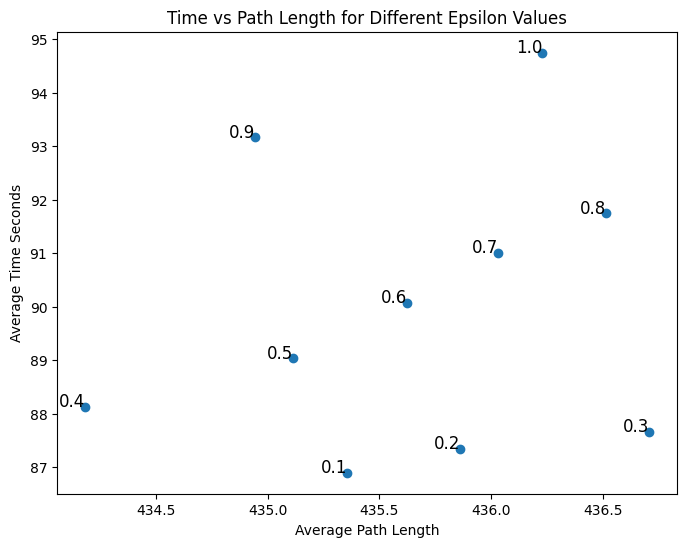

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Results/EpsilonSummary.csv")

plt.figure(figsize=(8, 6))
plt.scatter(df["AvgPathLength"], df["AvgTimeSeconds"])

for i in range(len(df)):
    eps = df["Epsilon"][i]
    x = df["AvgPathLength"][i]
    y = df["AvgTimeSeconds"][i]
    plt.text(x, y, f"{eps}", fontsize=12, ha="right")

plt.xlabel("Average Path Length")
plt.ylabel("Average Time Seconds")
plt.title("Time vs Path Length for Different Epsilon Values")
plt.show()


## Complete Code (Alpha Iterations)

In [11]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime
import csv

def read(instance_file):
    name = None
    dimension = None
    coords = []
    in_coord_section = False

    with open(instance_file, 'r') as infile:
        for line in infile:
            line = line.strip()
            if not line:
                continue

            if line.startswith("NODE_COORD_SECTION"):
                in_coord_section = True
                continue

            if not in_coord_section:
                if line.startswith("NAME"):
                    name = line.split(":", 1)[1].strip()
                elif line.startswith("DIMENSION"):
                    dimension = int(line.split(":", 1)[1].strip())
                continue

            if line.startswith("EOF"):
                break

            parts = line.split()
            if len(parts) < 3:
                continue

            _, x, y = parts[:3]
            coords.append([float(x), float(y)])

    return np.array(coords)


def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        path_length += distances[path[i]][path[i + 1]]
    return path_length


def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)


def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu

    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp


def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances,
                                                  delta, beta, mu, 0) for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]


def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])


def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            delta_pheromones[path[i]][path[i + 1]] += rewards

    pheromones += -rho * pheromones + delta_pheromones


def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_length = calculate_path_length(new_path, distances)
                if new_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_length
                    improved = True
        path = best_path
    return best_path


def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants,
                num_local_search_iterations, gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate,
                w_reward, rho, delta, beta, mu):

    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))

    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)

        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))

                allowed = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]

                if hop == num_cities - 1:
                    next_city = paths[ant][0]
                else:
                    next_city = choose_next_city(current_city, allowed, q_table, pheromones,
                                                 local_epsilon, distances, delta, beta, mu)

                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]

            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)

        best = np.argmin(path_lengths)
        best_path = paths[best]
        best_len = path_lengths[best]

        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_len = calculate_path_length(new_path, distances)
            if new_len < best_len:
                best_path = new_path
                best_len = new_len

        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)

        local_alpha *= 1 / (1 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)

    return best_path


global_params = {
    "alpha": 0.5,
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,
    "epsilon": 1.0,
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,
    "w_reward": 10,
    "num_local_search_iterations": 25,
    "mu": 2,
    "delta": 2,
    "beta": 3
}


def run_trial(trial, num_cities, distances, global_params):
    start = datetime.now()

    best_path = hybrid_qaco(
        global_params["alpha"], global_params["epsilon"],
        num_cities, distances,
        global_params["num_episodes"], global_params["num_ants"],
        global_params["num_local_search_iterations"], global_params["gamma"],
        global_params["alpha_decay_rate"], global_params["epsilon_min"],
        global_params["epsilon_decay_rate"], global_params["w_reward"],
        global_params["rho"], global_params["delta"], global_params["beta"],
        global_params["mu"]
    )

    length = calculate_path_length(best_path, distances)
    end = datetime.now()
    return trial, length, (end - start).total_seconds()


instances_dir = 'Instances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

os.makedirs("Results", exist_ok=True)
csv_file = "Results/CompleteAlgorithm.csv"

# Summary CSV for alpha sweep
summary_csv = "Results/AlphaSummary.csv"

# Fixed epsilon
fixed_epsilon = 0.4

# Alpha values 0.1 to 1.0
alpha_values = [round(i * 0.1, 1) for i in range(1, 11)]

with open(csv_file, mode='w', newline='') as file_all, open(summary_csv, mode='w', newline='') as file_sum:
    writer = csv.writer(file_all)
    writer_sum = csv.writer(file_sum)

    writer.writerow(["Instance", "Algorithm", "Alpha", "Trial", "PathLength", "TimeSeconds"])
    writer_sum.writerow(["Alpha", "AvgPathLength", "AvgTimeSeconds"])

    algorithm = "CompleteAlgorithm"

    for instance_file in instance_files:
        instance_name = os.path.basename(instance_file).replace(".tsp", "")

        print("\n=============================================")
        print(f"Processing instance: {instance_name}")

        cities = read(instance_file)
        num_cities = len(cities)

        distances = np.sqrt(
            (cities[:, None, 0] - cities[None, :, 0]) ** 2 +
            (cities[:, None, 1] - cities[None, :, 1]) ** 2
        )

        num_trials = 20

        for alpha in alpha_values:
            print(f"Alpha = {alpha}")

            local_params = global_params.copy()
            local_params["epsilon"] = fixed_epsilon
            local_params["alpha"] = alpha

            results = []

            with ProcessPoolExecutor(max_workers=num_trials) as executor:
                futures = [executor.submit(run_trial, trial, num_cities, distances, local_params)
                           for trial in range(1, num_trials + 1)]

                for future in as_completed(futures):
                    trial, length, tsec = future.result()
                    results.append((trial, length, tsec))

                    writer.writerow([instance_name,
                                     algorithm,
                                     alpha,
                                     trial,
                                     length,
                                     tsec])

            avg_len = np.mean([r[1] for r in results])
            avg_time = np.mean([r[2] for r in results])

            writer_sum.writerow([alpha, avg_len, avg_time])

print("\nSaved master CSV at:", csv_file)
print("Saved alpha summary at:", summary_csv)



Processing instance: eil51
Alpha = 0.1
Alpha = 0.2
Alpha = 0.3
Alpha = 0.4
Alpha = 0.5
Alpha = 0.6
Alpha = 0.7
Alpha = 0.8
Alpha = 0.9
Alpha = 1.0

Saved master CSV at: Results/CompleteAlgorithm.csv
Saved alpha summary at: Results/AlphaSummary.csv


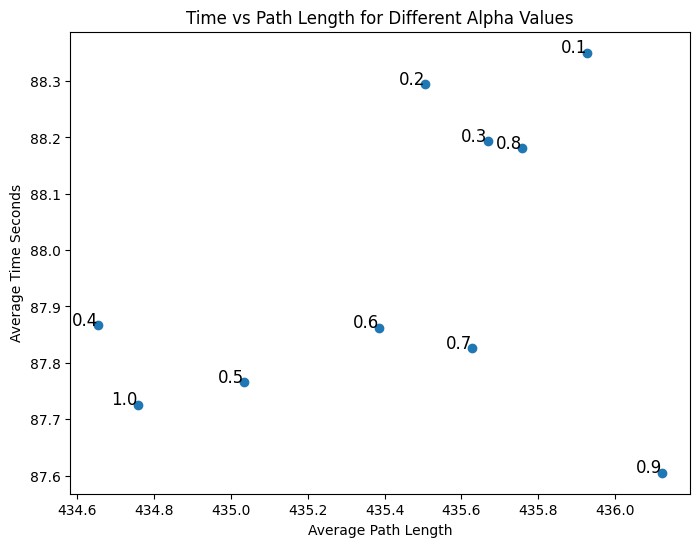

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Results/AlphaSummary.csv")

plt.figure(figsize=(8, 6))
plt.scatter(df["AvgPathLength"], df["AvgTimeSeconds"])

for i in range(len(df)):
    a = df["Alpha"][i]
    x = df["AvgPathLength"][i]
    y = df["AvgTimeSeconds"][i]
    plt.text(x, y, f"{a}", fontsize=12, ha="right")

plt.xlabel("Average Path Length")
plt.ylabel("Average Time Seconds")
plt.title("Time vs Path Length for Different Alpha Values")
plt.show()
